In [1]:
# Install LightGBM if it is not already installed.
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Import required libraries and functions.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

from lightgbm import LGBMClassifier

In [4]:
# Load the credit card fraud dataset.
ds = pd.read_csv(r"E:\random proj\lehrire\creditcard.csv")

# Display the number of rows and columns.
print(ds.shape)

(284807, 31)


In [5]:
# Display the name and data type of each column.
print(ds.dtypes)

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [7]:
# Display the first 5 rows of the dataset.
display(ds.head())
# Display the last 5 rows of the dataset.
display(ds.tail())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [8]:
ds.isna().sum().add((ds == '').sum()).add((ds == '?').sum()).add((ds == 'Unknown').sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
# Count duplicated rows before removing them.
print("Number of duplicate rows:", ds.duplicated().sum())

# Remove duplicate rows.
ds = ds.drop_duplicates()

# Verify that no duplicate rows remain.
print("Number of duplicate rows after removal:", ds.duplicated().sum())

Number of duplicate rows: 1081
Number of duplicate rows after removal: 0


Class
0    283253
1       473
Name: count, dtype: int64


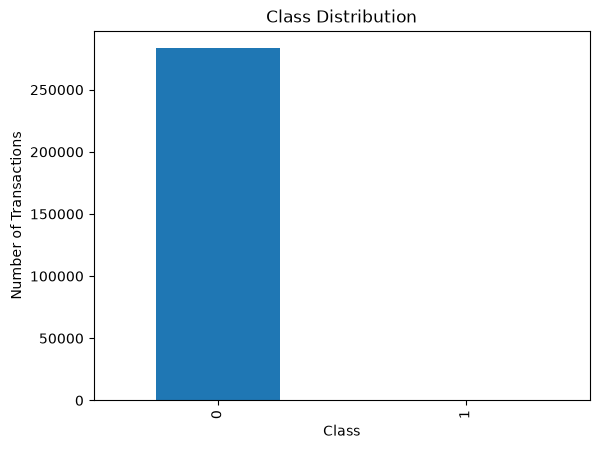

In [13]:
# Display the number of transactions in each class.
print(ds["Class"].value_counts())

# Visualize the class distribution.
ds["Class"].value_counts().plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.title("Class Distribution")
plt.show()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64


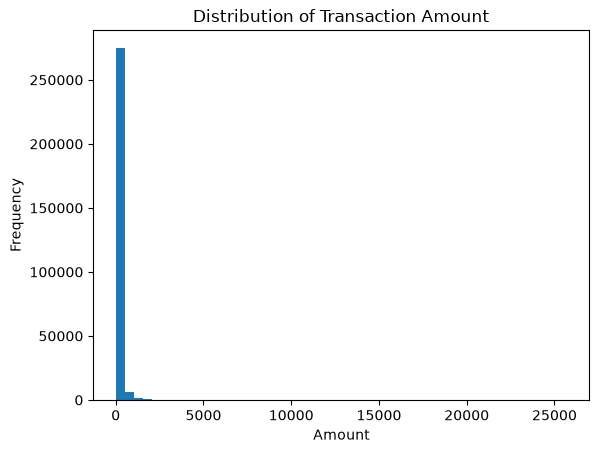

In [16]:
# Display descriptive statistics for transaction amounts.
print(ds["Amount"].describe())

# Plot the distribution of transaction amounts.
ds["Amount"].plot(kind="hist", bins=50)

plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Transaction Amount")
plt.show()

Amount skewness: 16.978803370060476


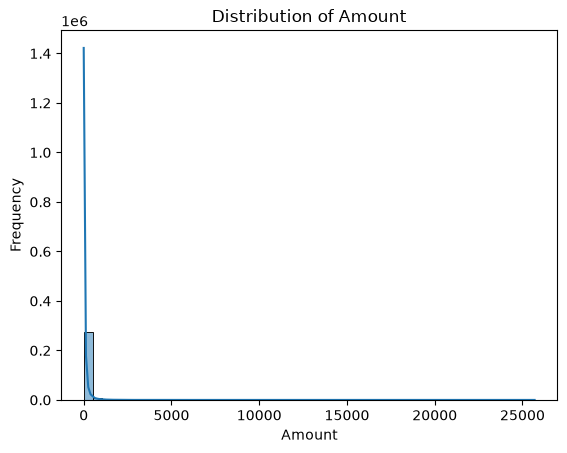

In [17]:
# Calculate the skewness of the Amount feature.
print("Amount skewness:", ds["Amount"].skew())

# Visualize the distribution with a density estimate.
sns.histplot(ds["Amount"], bins=50, kde=True)

plt.title("Distribution of Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

In [18]:
# Apply log transformation to reduce the right skew of Amount.
ds["Amount_log"] = np.log1p(ds["Amount"])

# Check the skewness after transformation.
print("Amount_log skewness:", ds["Amount_log"].skew())

Amount_log skewness: 0.16141018223366635


In [19]:
# Calculate the skewness of numerical features.
skewness = ds.drop(columns=["Class"]).skew().sort_values(ascending=False)

# Display the skewness values.
print(skewness)

Amount        16.978803
V28           11.555115
V7             2.890271
V21            2.820033
V6             1.829880
V10            1.252967
V4             0.671504
V26            0.580292
V9             0.537663
V11            0.344074
Amount_log     0.161410
V19            0.108312
V13            0.064293
Time          -0.035581
V22           -0.182330
V18           -0.248661
V15           -0.309659
V25           -0.415744
V24           -0.552129
V27           -0.753804
V16           -1.051161
V14           -1.918804
V20           -2.043121
V3            -2.151984
V12           -2.199008
V5            -2.414079
V1            -3.273271
V17           -3.690497
V2            -4.695162
V23           -5.867221
V8            -8.310970
dtype: float64


In [20]:
# Display the minimum and maximum transaction time.
print(ds["Time"].min())
print(ds["Time"].max())

# Check transactions around the 24-hour mark.
print("\nTransactions around 24 hours:")
print(ds[(ds["Time"] >= 86000) & (ds["Time"] <= 86800)]["Time"].head(20))

# Convert the maximum time from seconds to days.
print(ds["Time"].max() / 86400)

0.0
172792.0

Transactions around 24 hours:
144284    86001.0
144285    86001.0
144286    86001.0
144287    86003.0
144288    86004.0
144289    86005.0
144290    86006.0
144291    86006.0
144292    86007.0
144293    86007.0
144294    86008.0
144295    86010.0
144296    86010.0
144297    86011.0
144298    86011.0
144299    86012.0
144300    86013.0
144301    86013.0
144302    86015.0
144303    86016.0
Name: Time, dtype: float64
1.9999074074074075


In [21]:
X = ds.drop('Class', axis=1)# Extract the hour of the day from the transaction time.
ds["Hour"] = ((ds["Time"] % 86400) // 3600).astype(int)

# Extract the day number from the transaction time.
ds["Day"] = (ds["Time"] // 86400).astype(int)
y = ds['Class']

In [22]:
# Calculate the fraud rate for each day.
print("Fraud rate by Day:")
print(ds.groupby("Day")["Class"].mean())

# Calculate the fraud rate for each hour.
print("\nFraud rate by Hour:")
print(ds.groupby("Hour")["Class"].mean())

Fraud rate by Day:
Day
0    0.001886
1    0.001441
Name: Class, dtype: float64

Fraud rate by Hour:
Hour
0     0.000785
1     0.002376
2     0.014510
3     0.004875
4     0.010436
5     0.003681
6     0.002205
7     0.003180
8     0.000880
9     0.001015
10    0.000483
11    0.003158
12    0.001105
13    0.001109
14    0.001392
15    0.001588
16    0.001342
17    0.001736
18    0.001651
19    0.001221
20    0.001078
21    0.000908
22    0.000585
23    0.001562
Name: Class, dtype: float64


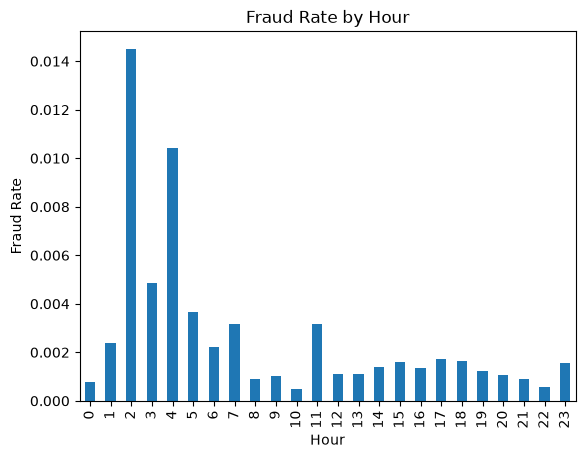

In [23]:
# Visualize the fraud rate by hour.
fraud_rate_by_hour = ds.groupby("Hour")["Class"].mean()

fraud_rate_by_hour.plot(kind="bar")

plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.title("Fraud Rate by Hour")
plt.show()

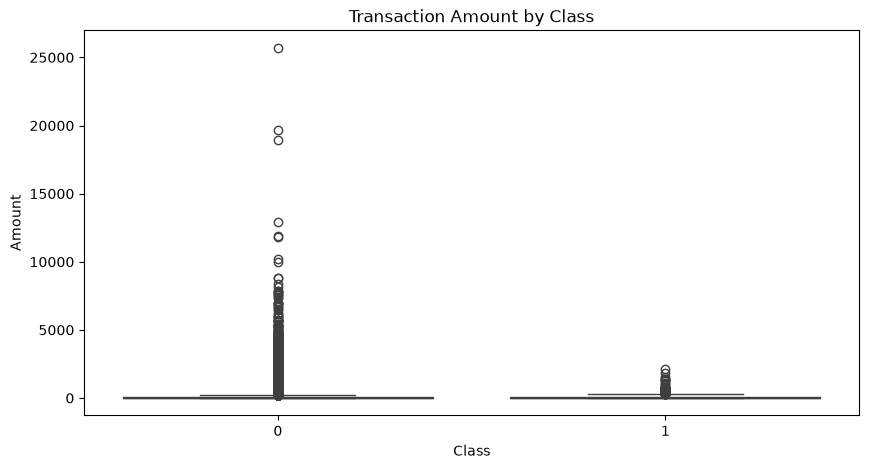

In [24]:
# Compare the distribution of transaction amounts between legitimate and fraudulent transactions.
plt.figure(figsize=(10, 5))

sns.boxplot(data=ds, x="Class", y="Amount")

plt.xlabel("Class")
plt.ylabel("Amount")
plt.title("Transaction Amount by Class")
plt.show()

In [25]:
# Display descriptive statistics of transaction amounts for each class.
print(ds.groupby("Class")["Amount"].describe())

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


In [26]:
# Separate features and target variable.
X = ds.drop(columns=["Class"])
y = ds["Class"]

In [27]:
# Split the dataset into training and temporary sets.
# The temporary set will later be divided into validation and test sets.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [28]:
# Split the temporary set equally into validation and test sets.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [29]:
# Display the size of each dataset.
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (198608, 33)
Validation set: (42559, 33)
Test set: (42559, 33)


In [30]:
# Display the class distribution in each dataset.
print("Training class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training class distribution:
Class
0    198277
1       331
Name: count, dtype: int64

Validation class distribution:
Class
0    42488
1       71
Name: count, dtype: int64

Test class distribution:
Class
0    42488
1       71
Name: count, dtype: int64


In [33]:
# Create and train the LightGBM model.
model = LGBMClassifier(
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully.")

[LightGBM] [Info] Number of positive: 331, number of negative: 198277
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.072775 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7931
[LightGBM] [Info] Number of data points in the train set: 198608, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Model trained successfully.


In [36]:
# Generate fraud probabilities for the validation set.
y_val_prob = model.predict_proba(X_val)[:, 1]

print("Validation probabilities generated successfully.")
print(y_val_prob[:10])

Validation probabilities generated successfully.
[2.61707152e-05 2.41877479e-05 2.73903935e-04 3.22061457e-05
 8.11842629e-05 2.81062070e-05 5.53213682e-05 5.69130353e-05
 4.44978777e-05 3.28776425e-05]


In [35]:
# Evaluate the model on the validation set using the default threshold.
y_val_pred_default = (y_val_prob >= 0.5).astype(int)

print(classification_report(y_val, y_val_pred_default))

print("Validation ROC-AUC:",
      roc_auc_score(y_val, y_val_prob))

print("Validation PR-AUC:",
      average_precision_score(y_val, y_val_prob))



              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42488
           1       0.90      0.76      0.82        71

    accuracy                           1.00     42559
   macro avg       0.95      0.88      0.91     42559
weighted avg       1.00      1.00      1.00     42559

Validation ROC-AUC: 0.9691793672977425
Validation PR-AUC: 0.8129140793646203


In [42]:
# Search for the best classification threshold using the validation set.
thresholds = np.arange(0.1, 1.0, 0.01)

best_threshold = 0
best_f1 = 0
best_precision = 0
best_recall = 0

for threshold in thresholds:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    precision = precision_score(y_val, y_val_pred, zero_division=0)
    recall = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)

    if f1 > best_f1:
        best_threshold = threshold
        best_f1 = f1
        best_precision = precision
        best_recall = recall

print("Best Threshold:", best_threshold)
print("Validation Precision:", best_precision)
print("Validation Recall:", best_recall)
print("Validation F1-score:", best_f1)

Best Threshold: 0.9699999999999995
Validation Precision: 0.9629629629629629
Validation Recall: 0.7323943661971831
Validation F1-score: 0.832


In [38]:
# Generate fraud probabilities for the test set.
y_test_prob = model.predict_proba(X_test)[:, 1]

# Convert probabilities to class predictions using the best validation threshold.
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print("Test probabilities generated successfully.")

Test probabilities generated successfully.


In [39]:
# Evaluate the final model on the untouched test set.
print("Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

print("Test Precision:", precision_score(y_test, y_test_pred, zero_division=0))
print("Test Recall:", recall_score(y_test, y_test_pred, zero_division=0))
print("Test F1-score:", f1_score(y_test, y_test_pred, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42488
           1       0.91      0.69      0.78        71

    accuracy                           1.00     42559
   macro avg       0.95      0.85      0.89     42559
weighted avg       1.00      1.00      1.00     42559

Test Precision: 0.9074074074074074
Test Recall: 0.6901408450704225
Test F1-score: 0.784


In [43]:
# Calculate ROC-AUC and PR-AUC using test probabilities.
roc_auc = roc_auc_score(y_test, y_test_prob)
pr_auc = average_precision_score(y_test, y_test_prob)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.931671013654891
PR-AUC: 0.7382052222192526


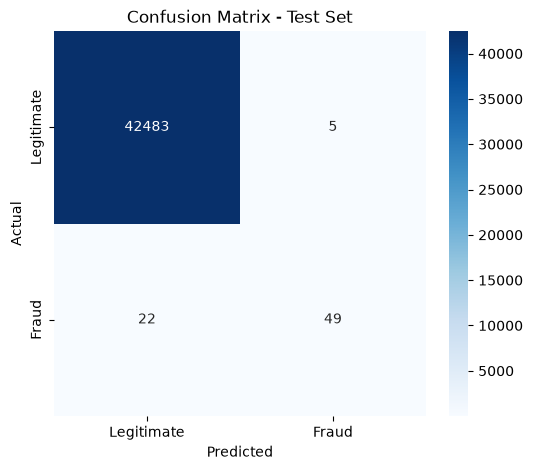

In [44]:
# Create the confusion matrix for the final test predictions.
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Set")
plt.show()

In [45]:
# Display the feature importance values of the trained LightGBM model.
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

# Sort features from most important to least important.
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
14,V14,263
4,V4,211
12,V12,152
3,V3,126
26,V26,112
13,V13,108
27,V27,105
28,V28,105
11,V11,104
24,V24,101


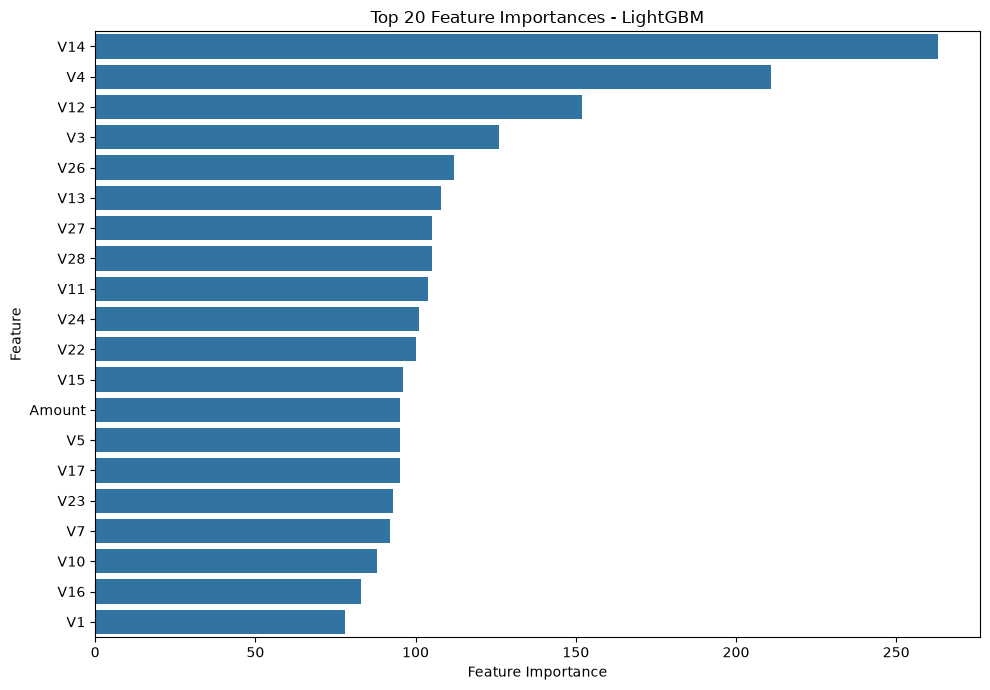

In [47]:
# Plot the top 20 most important features.
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances - LightGBM")
plt.tight_layout()
plt.show()

In [48]:
# Calculate the correlation of each numerical feature with the target.
correlation_with_class = (
    ds.corr(numeric_only=True)["Class"]
    .drop("Class")
    .abs()
    .sort_values(ascending=False)
)

# Display the features with the highest absolute correlation.
print(correlation_with_class)

V17           0.313498
V14           0.293375
V12           0.250711
V10           0.206971
V16           0.187186
V3            0.182322
V7            0.172347
V11           0.149067
V4            0.129326
V18           0.105340
V1            0.094486
V9            0.094021
V5            0.087812
V2            0.084624
V6            0.043915
V19           0.033631
V8            0.033068
V21           0.026357
V27           0.021892
V20           0.021486
Hour          0.016740
Time          0.012359
V28           0.009682
Amount_log    0.007798
V24           0.007210
V23           0.006333
Amount        0.005777
Day           0.005451
V22           0.004887
V26           0.004265
V13           0.003897
V15           0.003300
V25           0.003202
Name: Class, dtype: float64


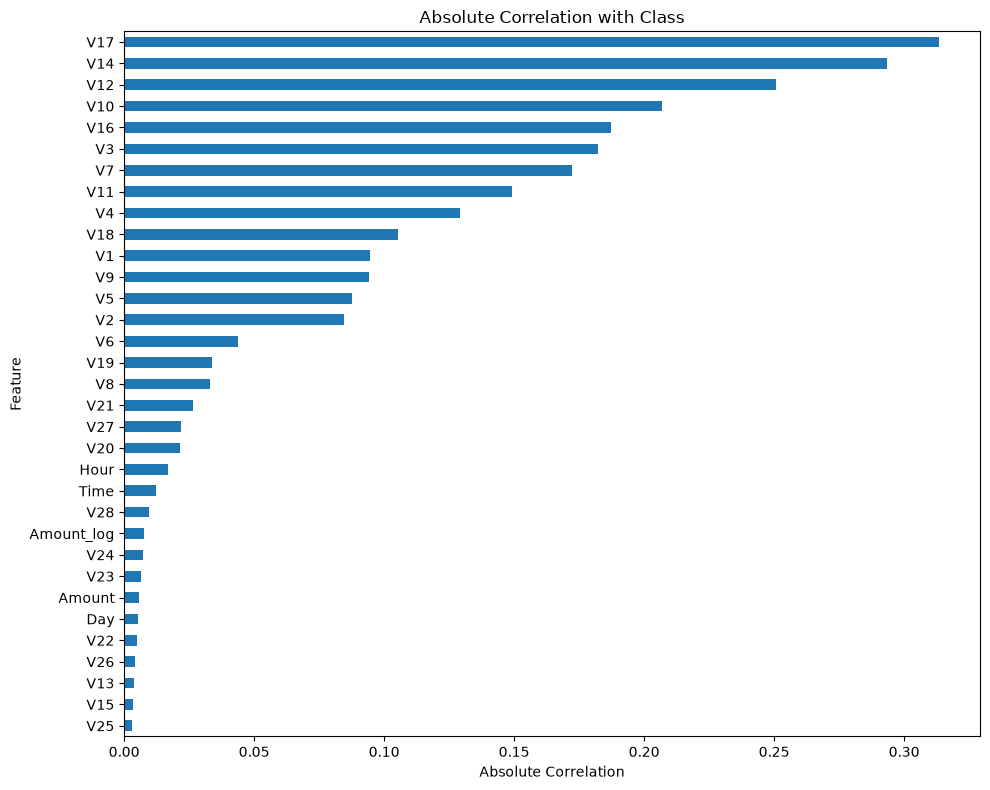

In [49]:
# Plot the absolute correlation of features with the target.
plt.figure(figsize=(10, 8))

correlation_with_class.sort_values().plot(
    kind="barh"
)

plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")
plt.title("Absolute Correlation with Class")
plt.tight_layout()
plt.show()

In [50]:
# Define the candidate values of k for feature selection.
k_values = [5, 10, 15, 20, 25, 28, 30]

print("Candidate k values:", k_values)

Candidate k values: [5, 10, 15, 20, 25, 28, 30]


In [51]:
# Test different values of k using the validation set.
# Feature selection is fitted only on the training data to avoid data leakage.

k_results = []

for k in k_values:
    selector = SelectKBest(
        score_func=mutual_info_classif,
        k=k
    )

    X_train_selected = selector.fit_transform(X_train, y_train)
    X_val_selected = selector.transform(X_val)

    model_k = LGBMClassifier(
        class_weight="balanced",
        random_state=42
    )

    model_k.fit(X_train_selected, y_train)

    y_val_prob_k = model_k.predict_proba(X_val_selected)[:, 1]

    y_val_pred_k = (y_val_prob_k >= 0.5).astype(int)

    f1_k = f1_score(
        y_val,
        y_val_pred_k,
        zero_division=0
    )

    k_results.append({
        "k": k,
        "Validation_F1": f1_k
    })

k_results_df = pd.DataFrame(k_results)

display(k_results_df)

[LightGBM] [Info] Number of positive: 331, number of negative: 198277
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003000 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1022
[LightGBM] [Info] Number of data points in the train set: 198608, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 331, number of negative: 198277
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007388 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2297
[LightGBM] [Info] Number of data points in the train set: 198608, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[Li

,k,Validation_F1
0,5,0.651163
1,10,0.791367
2,15,0.780142
3,20,0.797101
4,25,0.829630
5,28,0.835821
6,30,0.833333


In [52]:
# Select the k value that achieved the highest validation F1-score.
best_k = k_results_df.loc[
    k_results_df["Validation_F1"].idxmax(),
    "k"
]

print("Best k:", best_k)

Best k: 28


In [53]:
# Fit the final feature selector using only the training data.
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=int(best_k)
)

X_train_selected = selector.fit_transform(X_train, y_train)
X_val_selected = selector.transform(X_val)
X_test_selected = selector.transform(X_test)

# Get the names of the selected features.
selected_features = X_train.columns[selector.get_support()]

print("Selected features:")
print(selected_features.tolist())

Selected features:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V23', 'V25', 'V27', 'V28', 'Amount', 'Amount_log', 'Hour', 'Day']


In [54]:
# Train the final LightGBM model using the selected features.
model = LGBMClassifier(
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_selected, y_train)

print("Final model trained successfully.")

[LightGBM] [Info] Number of positive: 331, number of negative: 198277
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014994 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6656
[LightGBM] [Info] Number of data points in the train set: 198608, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Final model trained successfully.


In [55]:
# Generate fraud probabilities for the validation set using the final model.
y_val_prob = model.predict_proba(X_val_selected)[:, 1]

print("Validation probabilities generated successfully.")
print(y_val_prob[:10])

Validation probabilities generated successfully.
[3.49246426e-05 2.01336408e-05 1.35773823e-03 1.94019570e-04
 8.99379136e-05 2.76468886e-05 2.60741029e-05 9.15531759e-05
 4.39434879e-05 9.64900949e-05]


In [56]:
# Search for the best classification threshold on the validation set.
thresholds = np.arange(0.1, 1.0, 0.01)

best_threshold = 0
best_f1 = 0
best_precision = 0
best_recall = 0

for threshold in thresholds:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    precision = precision_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    if f1 > best_f1:
        best_threshold = threshold
        best_f1 = f1
        best_precision = precision
        best_recall = recall

print("Best Threshold:", best_threshold)
print("Validation Precision:", best_precision)
print("Validation Recall:", best_recall)
print("Validation F1-score:", best_f1)

Best Threshold: 0.6099999999999998
Validation Precision: 0.9180327868852459
Validation Recall: 0.7887323943661971
Validation F1-score: 0.8484848484848485


In [57]:
# Generate fraud probabilities for the test set using the final model.
y_test_prob = model.predict_proba(X_test_selected)[:, 1]

# Apply the best threshold found on the validation set.
y_test_pred = (y_test_prob >= best_threshold).astype(int)

print("Test predictions generated successfully.")

Test predictions generated successfully.


In [58]:
# Evaluate the final model on the untouched test set.
print("Classification Report:")
print(classification_report(
    y_test,
    y_test_pred,
    zero_division=0
))

print("Test Precision:", precision_score(
    y_test,
    y_test_pred,
    zero_division=0
))

print("Test Recall:", recall_score(
    y_test,
    y_test_pred,
    zero_division=0
))

print("Test F1-score:", f1_score(
    y_test,
    y_test_pred,
    zero_division=0
))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42488
           1       0.85      0.80      0.83        71

    accuracy                           1.00     42559
   macro avg       0.93      0.90      0.91     42559
weighted avg       1.00      1.00      1.00     42559

Test Precision: 0.8507462686567164
Test Recall: 0.8028169014084507
Test F1-score: 0.8260869565217391


In [59]:
# Calculate ROC-AUC and PR-AUC using the test probabilities.
roc_auc = roc_auc_score(
    y_test,
    y_test_prob
)

pr_auc = average_precision_score(
    y_test,
    y_test_prob
)

print("Test ROC-AUC:", roc_auc)
print("Test PR-AUC:", pr_auc)

Test ROC-AUC: 0.9742356416791087
Test PR-AUC: 0.7941784191208283


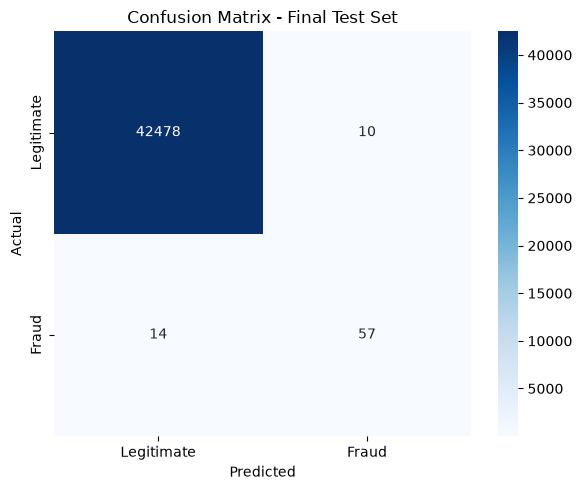

In [60]:
# Create the confusion matrix for the final test predictions.
cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Test Set")
plt.tight_layout()
plt.show()

In [61]:
# Create a DataFrame containing the final evaluation metrics.
final_metrics = pd.DataFrame({
    "Metric": [
        "Best k",
        "Best Threshold",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value": [
        best_k,
        best_threshold,
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0),
        roc_auc,
        pr_auc
    ]
})

display(final_metrics)

,Metric,Value
0,Best k,28.000000
1,Best Threshold,0.610000
2,Precision,0.850746
3,Recall,0.802817
4,F1-score,0.826087
5,ROC-AUC,0.974236
6,PR-AUC,0.794178


In [62]:
# Extract the feature importance values from the final LightGBM model.
final_feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": model.feature_importances_
})

# Sort features from most important to least important.
final_feature_importance = final_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(final_feature_importance)

,Feature,Importance
4,V4,263
13,V14,222
12,V12,186
24,Amount,127
10,V10,119
18,V20,117
3,V3,117
11,V11,116
7,V7,113
20,V23,111


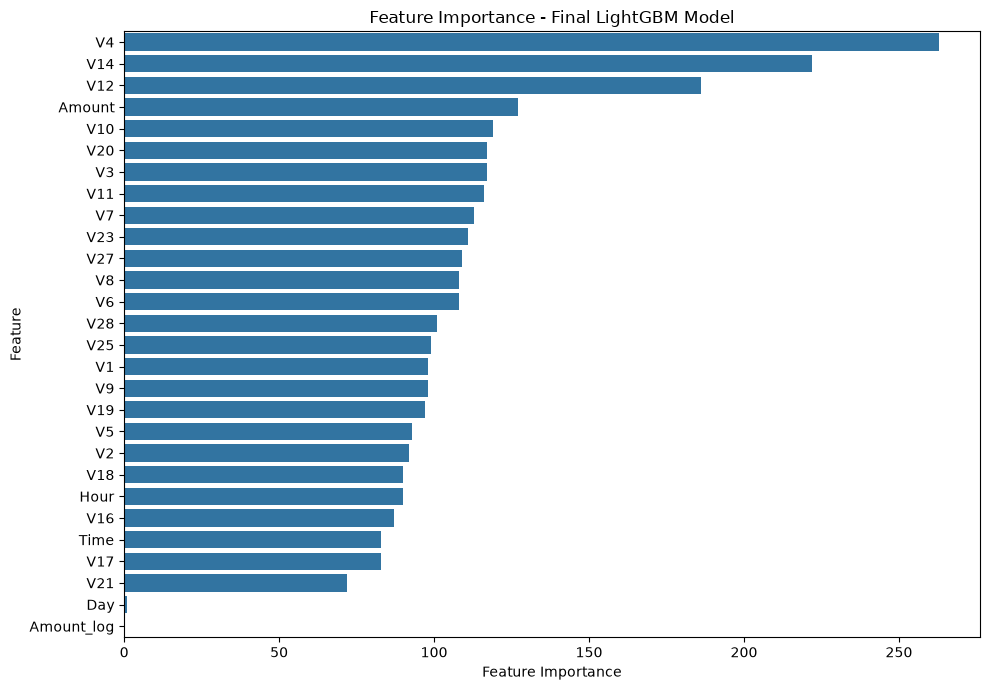

In [63]:
# Plot feature importance for the selected features.
plt.figure(figsize=(10, 7))

sns.barplot(
    data=final_feature_importance,
    x="Importance",
    y="Feature"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Final LightGBM Model")
plt.tight_layout()
plt.show()

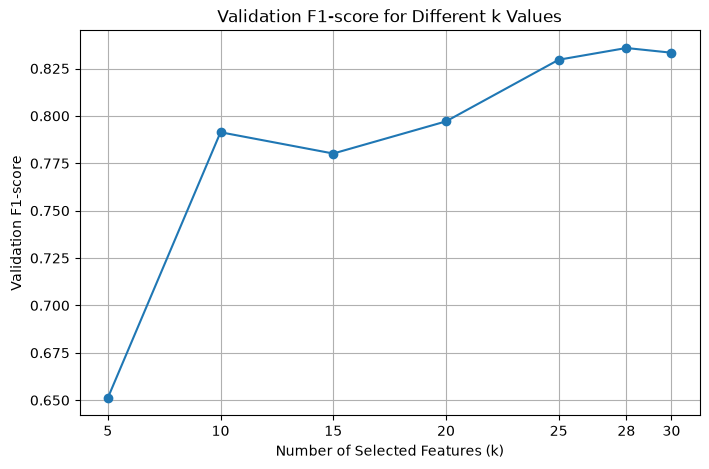

In [64]:
# Plot validation F1-score for all tested k values.
plt.figure(figsize=(8, 5))

plt.plot(
    k_results_df["k"],
    k_results_df["Validation_F1"],
    marker="o"
)

plt.xlabel("Number of Selected Features (k)")
plt.ylabel("Validation F1-score")
plt.title("Validation F1-score for Different k Values")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [65]:
# Display the final selected features.
print("Number of selected features:", len(selected_features))
print("\nSelected features:")

for feature in selected_features:
    print(feature)

Number of selected features: 28

Selected features:
Time
V1
V2
V3
V4
V5
V6
V7
V8
V9
V10
V11
V12
V14
V16
V17
V18
V19
V20
V21
V23
V25
V27
V28
Amount
Amount_log
Hour
Day


In [66]:
# Save the final evaluation metrics to a CSV file.
final_metrics.to_csv(
    "final_model_metrics.csv",
    index=False
)

print("Final metrics saved to final_model_metrics.csv")

Final metrics saved to final_model_metrics.csv


In [67]:
# Save the selected feature names to a CSV file.
pd.DataFrame({
    "Selected_Feature": selected_features
}).to_csv(
    "selected_features.csv",
    index=False
)

print("Selected features saved to selected_features.csv")

Selected features saved to selected_features.csv


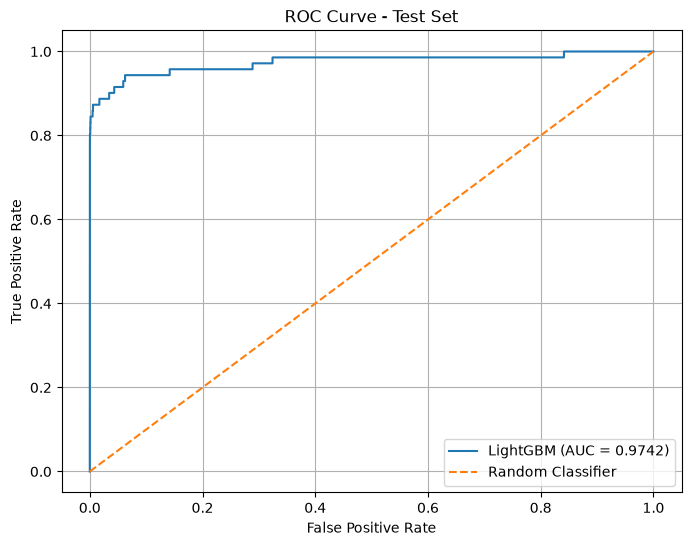

In [68]:
# Calculate ROC curve values for the final test predictions.
from sklearn.metrics import roc_curve

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_test_prob
)

# Plot the ROC curve.
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"LightGBM (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.grid(True)
plt.show()

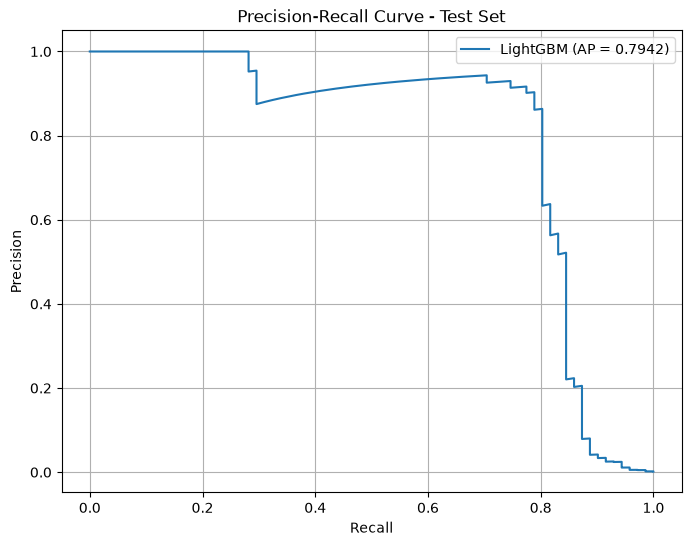

In [69]:
# Calculate Precision-Recall curve values for the final test predictions.
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test,
    y_test_prob
)

# Plot the Precision-Recall curve.
plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    label=f"LightGBM (AP = {pr_auc:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Test Set")
plt.legend()
plt.grid(True)
plt.show()

In [70]:
# Calculate precision, recall, and F1-score for each validation threshold.
threshold_results = []

for threshold in thresholds:
    y_val_pred = (y_val_prob >= threshold).astype(int)

    threshold_precision = precision_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    threshold_recall = recall_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    threshold_f1 = f1_score(
        y_val,
        y_val_pred,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": threshold_precision,
        "Recall": threshold_recall,
        "F1-score": threshold_f1
    })

threshold_results_df = pd.DataFrame(threshold_results)

display(threshold_results_df)

,Threshold,Precision,Recall,F1-score
0,0.10,0.651685,0.816901,0.725000
1,0.11,0.698795,0.816901,0.753247
2,0.12,0.712500,0.802817,0.754967
3,0.13,0.740260,0.802817,0.770270
4,0.14,0.750000,0.802817,0.775510
...,...,...,...,...
85,0.95,0.945455,0.732394,0.825397
86,0.96,0.945455,0.732394,0.825397
87,0.97,0.945455,0.732394,0.825397
88,0.98,0.962963,0.732394,0.832000


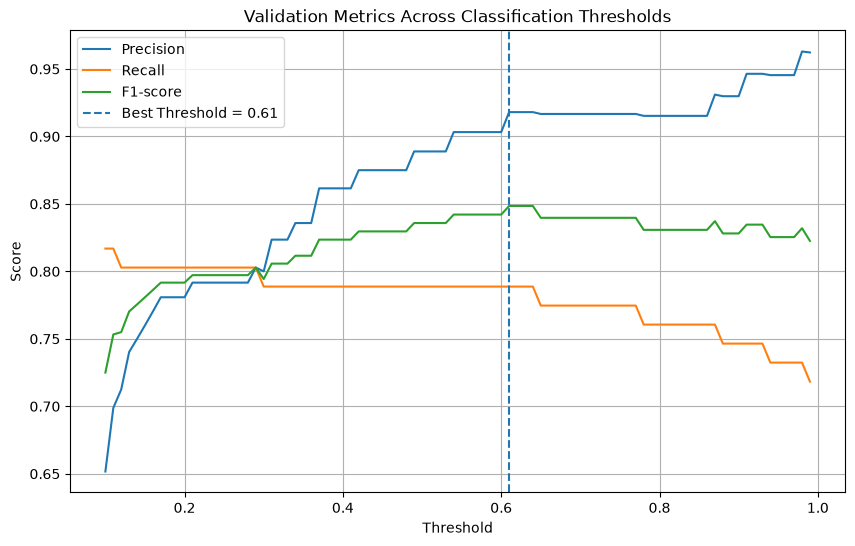

In [71]:
# Plot precision, recall, and F1-score across different thresholds.
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1-score"],
    label="F1-score"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Validation Metrics Across Classification Thresholds")
plt.legend()
plt.grid(True)
plt.show()

In [72]:
# Save the final LightGBM model and feature selector.
import joblib

joblib.dump(
    model,
    "final_lightgbm_model.pkl"
)

joblib.dump(
    selector,
    "feature_selector.pkl"
)

print("Final model and feature selector saved successfully.")

Final model and feature selector saved successfully.


In [73]:
# Display a final summary of the model configuration and performance.
print("===== FINAL MODEL SUMMARY =====")
print("Model: LightGBM")
print("Best k:", best_k)
print("Number of selected features:", len(selected_features))
print("Best validation threshold:", best_threshold)
print("Test Precision:", precision_score(y_test, y_test_pred, zero_division=0))
print("Test Recall:", recall_score(y_test, y_test_pred, zero_division=0))
print("Test F1-score:", f1_score(y_test, y_test_pred, zero_division=0))
print("Test ROC-AUC:", roc_auc)
print("Test PR-AUC:", pr_auc)

===== FINAL MODEL SUMMARY =====
Model: LightGBM
Best k: 28
Number of selected features: 28
Best validation threshold: 0.6099999999999998
Test Precision: 0.8507462686567164
Test Recall: 0.8028169014084507
Test F1-score: 0.8260869565217391
Test ROC-AUC: 0.9742356416791087
Test PR-AUC: 0.7941784191208283


In [74]:
# Verify that the saved model can be loaded correctly.
loaded_model = joblib.load("final_lightgbm_model.pkl")

# Verify that the saved feature selector can be loaded correctly.
loaded_selector = joblib.load("feature_selector.pkl")

print("Model loaded successfully:", type(loaded_model).__name__)
print("Feature selector loaded successfully:", type(loaded_selector).__name__)

Model loaded successfully: LGBMClassifier
Feature selector loaded successfully: SelectKBest


In [75]:
# Generate predictions using the reloaded model and feature selector.
X_test_loaded = loaded_selector.transform(X_test)

y_test_prob_loaded = loaded_model.predict_proba(X_test_loaded)[:, 1]

y_test_pred_loaded = (
    y_test_prob_loaded >= best_threshold
).astype(int)

print("Predictions generated successfully.")

Predictions generated successfully.


In [76]:
# Verify that the reloaded model produces the same predictions as the original model.
predictions_match = np.array_equal(
    y_test_pred,
    y_test_pred_loaded
)

print("Predictions match:", predictions_match)

Predictions match: True


In [77]:
# Check the final number of features used by the model.
print("Original number of features:", X_train.shape[1])
print("Selected number of features:", X_train_selected.shape[1])
print("Best k:", best_k)

Original number of features: 33
Selected number of features: 28
Best k: 28


In [78]:
# Display the final selected feature names in a clean table.
selected_features_df = pd.DataFrame({
    "Feature": selected_features
})

display(selected_features_df)

,Feature
0,Time
1,V1
2,V2
3,V3
4,V4
5,V5
6,V6
7,V7
8,V8
9,V9


In [79]:
# Save the complete threshold evaluation results.
threshold_results_df.to_csv(
    "threshold_results.csv",
    index=False
)

# Save the k-selection results.
k_results_df.to_csv(
    "k_selection_results.csv",
    index=False
)

print("Threshold and k-selection results saved successfully.")

Threshold and k-selection results saved successfully.


In [80]:
# Final verification of the main project outputs.
print("===== PROJECT OUTPUTS =====")
print("Best k:", best_k)
print("Best threshold:", best_threshold)
print("Selected features:", len(selected_features))
print("Test F1-score:", f1_score(y_test, y_test_pred, zero_division=0))
print("Test ROC-AUC:", roc_auc)
print("Test PR-AUC:", pr_auc)
print("Model file: final_lightgbm_model.pkl")
print("Selector file: feature_selector.pkl")
print("Metrics file: final_model_metrics.csv")
print("Threshold file: threshold_results.csv")
print("K-selection file: k_selection_results.csv")

===== PROJECT OUTPUTS =====
Best k: 28
Best threshold: 0.6099999999999998
Selected features: 28
Test F1-score: 0.8260869565217391
Test ROC-AUC: 0.9742356416791087
Test PR-AUC: 0.7941784191208283
Model file: final_lightgbm_model.pkl
Selector file: feature_selector.pkl
Metrics file: final_model_metrics.csv
Threshold file: threshold_results.csv
K-selection file: k_selection_results.csv


In [81]:
# Create a final summary table containing the main dataset and model information.
project_summary = pd.DataFrame({
    "Item": [
        "Total samples",
        "Training samples",
        "Validation samples",
        "Test samples",
        "Original features",
        "Selected features",
        "Best k",
        "Best threshold",
        "Test Precision",
        "Test Recall",
        "Test F1-score",
        "Test ROC-AUC",
        "Test PR-AUC"
    ],
    "Value": [
        len(ds),
        len(X_train),
        len(X_val),
        len(X_test),
        X_train.shape[1],
        len(selected_features),
        best_k,
        best_threshold,
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0),
        roc_auc,
        pr_auc
    ]
})

display(project_summary)

,Item,Value
0,Total samples,283726.000000
1,Training samples,198608.000000
2,Validation samples,42559.000000
3,Test samples,42559.000000
4,Original features,33.000000
5,Selected features,28.000000
6,Best k,28.000000
7,Best threshold,0.610000
8,Test Precision,0.850746
9,Test Recall,0.802817


In [82]:
# Save the final project summary.
project_summary.to_csv(
    "project_summary.csv",
    index=False
)

print("Project summary saved successfully.")

Project summary saved successfully.


In [83]:
# Verify that all important output files exist.
import os

output_files = [
    "final_lightgbm_model.pkl",
    "feature_selector.pkl",
    "final_model_metrics.csv",
    "selected_features.csv",
    "threshold_results.csv",
    "k_selection_results.csv",
    "project_summary.csv"
]

for file in output_files:
    print(f"{file}: {'OK' if os.path.exists(file) else 'MISSING'}")

final_lightgbm_model.pkl: OK
feature_selector.pkl: OK
final_model_metrics.csv: OK
selected_features.csv: OK
threshold_results.csv: OK
k_selection_results.csv: OK
project_summary.csv: OK


In [84]:
# Display the final confusion matrix values.
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred
).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 42478
False Positives: 10
False Negatives: 14
True Positives: 57


In [85]:
# Calculate the fraud detection rate and false positive rate.
fraud_detection_rate = tp / (tp + fn)
false_positive_rate = fp / (fp + tn)

print("Fraud Detection Rate:", fraud_detection_rate)
print("False Positive Rate:", false_positive_rate)

Fraud Detection Rate: 0.8028169014084507
False Positive Rate: 0.00023536057239691206
